In [3]:
import numpy as np 
arr = np.array([[1,2,3],[4,5,6]])
print(arr.shape)
print(arr.ndim)
print(arr.size)
print(arr.dtype)
zeros = np.zeros((3, 4))
ones = np.ones((2, 3))
print(zeros)
print(ones)
lin = np.linspace(0,1,4)
print(lin)



(2, 3)
2
6
int64
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[1. 1. 1.]
 [1. 1. 1.]]
[0.         0.33333333 0.66666667 1.        ]


In [11]:
data = np.random.rand(4, 5)
print(data)
print(data[0])
print(data[1:3, 2:4])
print(data[::2, ::2])

[[0.91163925 0.98773712 0.64102296 0.35401428 0.30136814]
 [0.10805041 0.48248921 0.92177395 0.89734463 0.81319968]
 [0.17276148 0.18501268 0.88495953 0.06822778 0.12028529]
 [0.11543326 0.94401199 0.86856499 0.74098071 0.27720107]]
[0.91163925 0.98773712 0.64102296 0.35401428 0.30136814]
[[0.92177395 0.89734463]
 [0.88495953 0.06822778]]
[[0.91163925 0.64102296 0.30136814]
 [0.17276148 0.88495953 0.12028529]]


In [14]:
temp = np.random.rand(3, 4)
lapse_rate = np.array([6.5, 6.0, 5.5, 5.0])
print(temp)
temp_adjusted = temp - lapse_rate*0.01
print(temp_adjusted)

[[0.2957144  0.33164193 0.86000375 0.80757525]
 [0.74767174 0.21308667 0.30526046 0.42954344]
 [0.98641325 0.28114769 0.70868492 0.60504025]]
[[0.2307144  0.27164193 0.80500375 0.75757525]
 [0.68267174 0.15308667 0.25026046 0.37954344]
 [0.92141325 0.22114769 0.65368492 0.55504025]]


In [19]:
data = np.array([1, 2, np.nan, 4, 5])
print(np.nanmean(data))

field = np.random.rand(5, 10)
zonal_mean = field.mean(axis=1)
print(zonal_mean)


3.0
[0.6955603  0.32026272 0.46889881 0.54448076 0.52923062]


In [ ]:
import pandas as pd
temps = pd.Series([28, 4, 1, 5],
                  index=['a', 'b', 'c', 'd'],
                  name='temprate')
print(temps['a'])

df = pd.DataFrame({
    'temprate':[4, 5, 6, 3],
    'wet': [4, 8, 54,4],
    'wind':[4, 2, 6, 7]
},
index=['a', 'b', 'c', 'd'])
print(df)



28
   temprate  wet  wind
a         4    4     4
b         5    8     2
c         6   54     6
d         3    4     7


In [47]:
dates = pd.date_range('2024-01-01', '2024-12-31', freq='D')
hourly = pd.date_range('2024-01-01', '2024-01-02', freq='h')
obs = pd.DataFrame({
    'temp': np.random.randn(366) * 5 + 20,
    'precip': np.random.exponential(2, 366),
}, index=dates)
monthly = obs.resample('ME').mean()
summer_mean = obs['2024-06':'2024-08'].mean()
obs['temp_smooth'] = obs['temp'].rolling(window=7).mean()
print(obs['temp_smooth'].head(10))

2024-01-01          NaN
2024-01-02          NaN
2024-01-03          NaN
2024-01-04          NaN
2024-01-05          NaN
2024-01-06          NaN
2024-01-07    19.530186
2024-01-08    19.401405
2024-01-09    20.026071
2024-01-10    19.582918
Freq: D, Name: temp_smooth, dtype: float64


In [49]:
# 假设是多个站点的观测数据
stations = pd.DataFrame({
    '站号': ['58238', '58321', '58457', '58527'],
    '站名': ['南京', '合肥', '杭州', '南昌'],
    '经度': [118.8, 117.3, 120.2, 115.9],
    '纬度': [32.0, 31.9, 30.2, 28.6],
    '海拔': [35.2, 27.0, 41.7, 46.3],
})

# 条件筛选
高海拔 = stations[stations['海拔'] > 40]
南方站 = stations[stations['纬度'] < 31]

# 分组统计（按区域等）
obs['季节'] = obs.index.month.map({
    12: 'DJF', 1: 'DJF', 2: 'DJF',
    3: 'MAM', 4: 'MAM', 5: 'MAM',
    6: 'JJA', 7: 'JJA', 8: 'JJA',
    9: 'SON', 10: 'SON', 11: 'SON'
})
seasonal = obs.groupby('季节')['temp'].agg(['mean', 'std', 'max', 'min'])
print(seasonal)

          mean       std        max       min
季节                                           
DJF  20.239942  5.254493  32.379313  5.277224
JJA  19.402281  5.040813  31.656497  6.750979
MAM  19.901296  5.168094  32.773933  8.228630
SON  19.584288  4.900305  32.443859  8.680982


In [50]:
obs_with_na = obs.copy()
obs_with_na.loc['2024-07-15', 'precip'] = np.nan

# 处理方式
obs_with_na.dropna()                             # 删掉含NaN的行
obs_with_na.fillna(0)                            # 降水量缺测填0
obs_with_na['precip'].interpolate(method='linear') 

2024-01-01    2.423869
2024-01-02    0.187782
2024-01-03    4.120857
2024-01-04    0.756925
2024-01-05    0.078386
                ...   
2024-12-27    0.563369
2024-12-28    5.484013
2024-12-29    0.465677
2024-12-30    4.286688
2024-12-31    0.257040
Freq: D, Name: precip, Length: 366, dtype: float64

(array([   12.,   138.,   958.,  3937.,  9067., 10358.,  6313.,  2096.,
          391.,    36.]),
 array([-1.48212406,  2.61421868,  6.71056143, 10.80690417, 14.90324692,
        18.99958966, 23.09593241, 27.19227515, 31.28861789, 35.38496064,
        39.48130338]),
 <BarContainer object of 10 artists>)

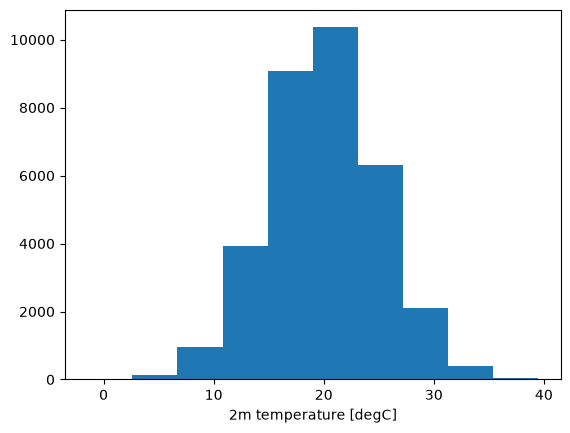

In [62]:
import xarray as xr
import numpy as np
time = pd.date_range('2024-01-01', '2024-12-31', freq='D')
lat = np.linspace(20, 50, 7)    # 7个纬度格点
lon = np.linspace(100, 130, 13) # 13个经度格点
temp_data = np.random.randn(len(time), len(lat), len(lon)) * 5 + 20
da_temp = xr.DataArray(
    temp_data,
    dims=['time', 'lat', 'lon'],
    coords={
        'time': time,
        'lat': lat,
        'lon': lon,
    },
    name='temperature',
    attrs={'units': 'degC', 'long_name': '2m temperature'}
)
da_temp.plot()

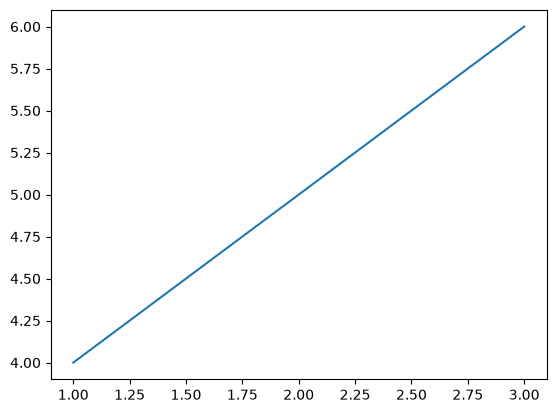

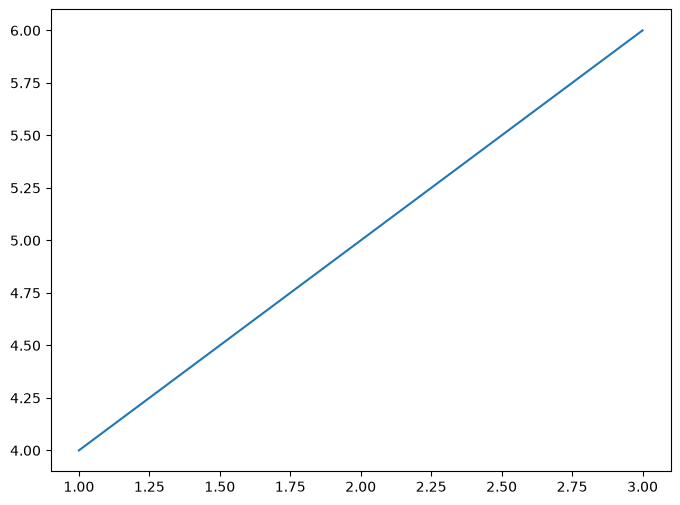

In [63]:
import matplotlib.pyplot as plt

# 两种画图风格
# 1. pyplot 风格（快速）
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

# 2. 面向对象风格（推荐，更灵活）
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([1, 2, 3], [4, 5, 6])
plt.show()

ValueError: cannot reshape array of size 366 into shape (30)

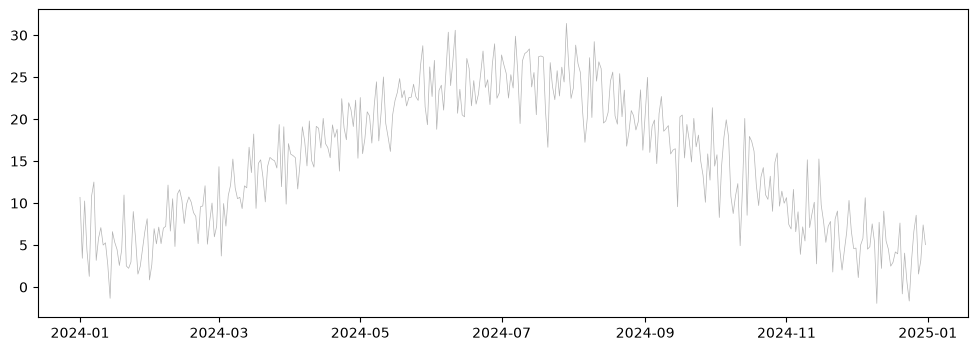

In [66]:
dates = pd.date_range('2024-01-01', '2024-12-31', freq='D')
temp = 15 + 10 * np.sin(2 * np.pi * np.arange(366) / 366 - np.pi/2) + np.random.randn(366) * 3

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, temp, linewidth=0.5, color='gray', alpha=0.6)
ax.plot(dates, temp.reshape(-1, 30).mean(axis=1).repeat(30),  # 30日滑动平均
        linewidth=2, color='red', label='30-day avg')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Nanjing Daily Temperature 2024')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

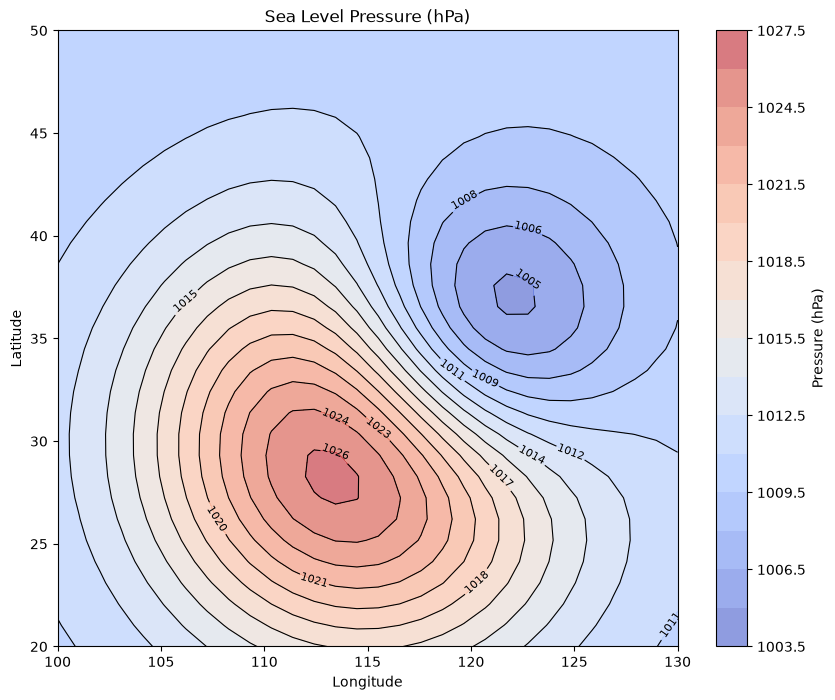

In [67]:
lon = np.linspace(100, 130, 30)
lat = np.linspace(20, 50, 30)
lon2d, lat2d = np.meshgrid(lon, lat)

# 构造一个低压系统
center_lon, center_lat = 115, 30
dist = np.sqrt((lon2d - center_lon)**2 + (lat2d - center_lat)**2)
pressure = 1010 + 20 * np.exp(-dist**2 / 100) - 15 * np.exp(-((lon2d-120)**2 + (lat2d-35)**2) / 50)

fig, ax = plt.subplots(figsize=(10, 8))
contour = ax.contour(lon2d, lat2d, pressure, levels=15, colors='black', linewidths=0.8)
ax.clabel(contour, inline=True, fontsize=8, fmt='%d')
contourf = ax.contourf(lon2d, lat2d, pressure, levels=15, cmap='coolwarm', alpha=0.6)
fig.colorbar(contourf, ax=ax, label='Pressure (hPa)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Sea Level Pressure (hPa)')
plt.show()

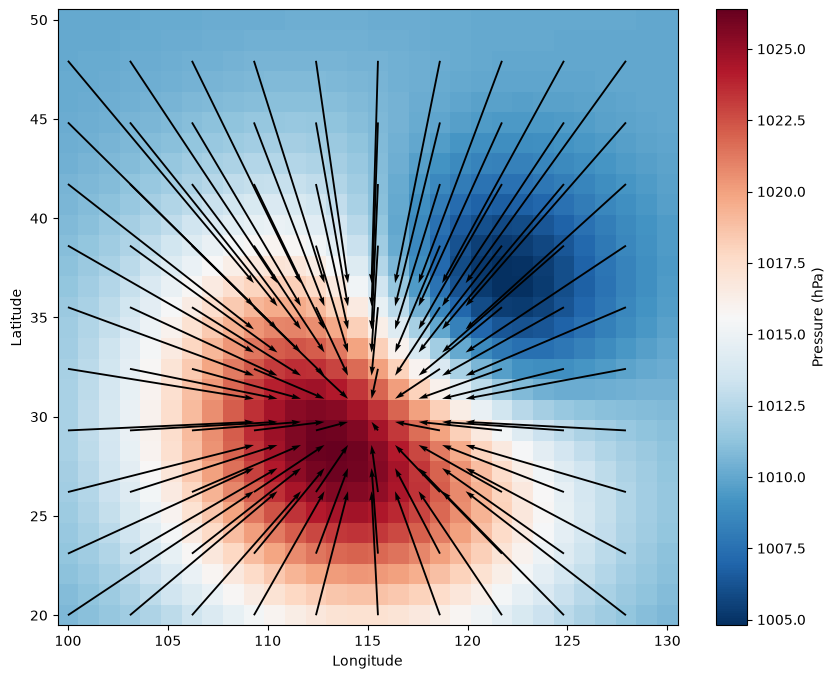

In [68]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(lon2d, lat2d, pressure, cmap='RdBu_r', shading='auto')
fig.colorbar(im, ax=ax, label='Pressure (hPa)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

# 风场叠加（用 quiver）
u = - (lon2d - center_lon)  # 流向低压
v = - (lat2d - center_lat)
ax.quiver(lon2d[::3, ::3], lat2d[::3, ::3], u[::3, ::3], v[::3, ::3],
          scale=50, width=0.003)
plt.show()

TypeError: Shapes of x (30, 30) and z (7, 13) do not match

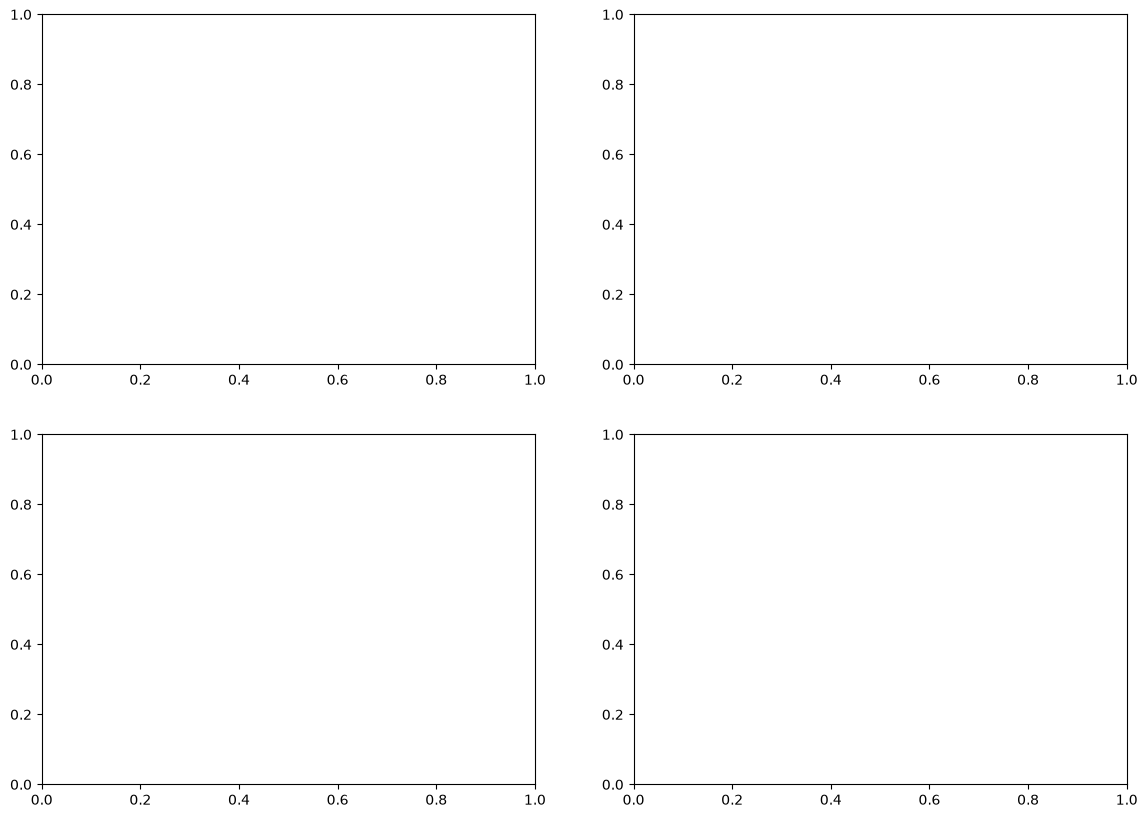

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 四个子图：不同时间的温度场
for i, t in enumerate(['Jan', 'Apr', 'Jul', 'Oct']):
    data = da_temp.sel(time=f'2024-{["01","04","07","10"][i]}-15')
    axes[i].contourf(lon2d, lat2d, data.values, cmap='RdBu_r')
    axes[i].set_title(t)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

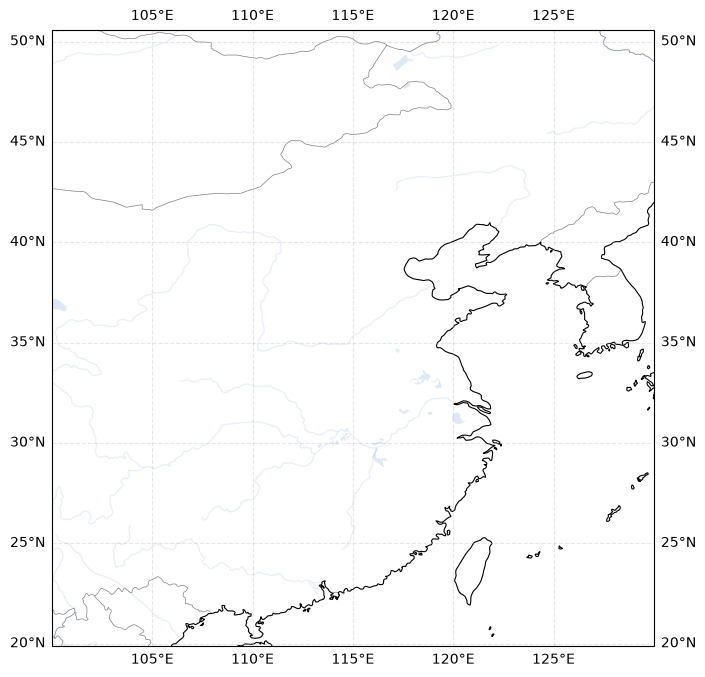

In [77]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 第一个地图
fig, ax = plt.subplots(figsize=(10, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines(resolution='50m', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.3)
ax.add_feature(cfeature.RIVERS, alpha=0.2)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
ax.set_extent([100, 130, 20, 50])  # 中国东部
plt.show()

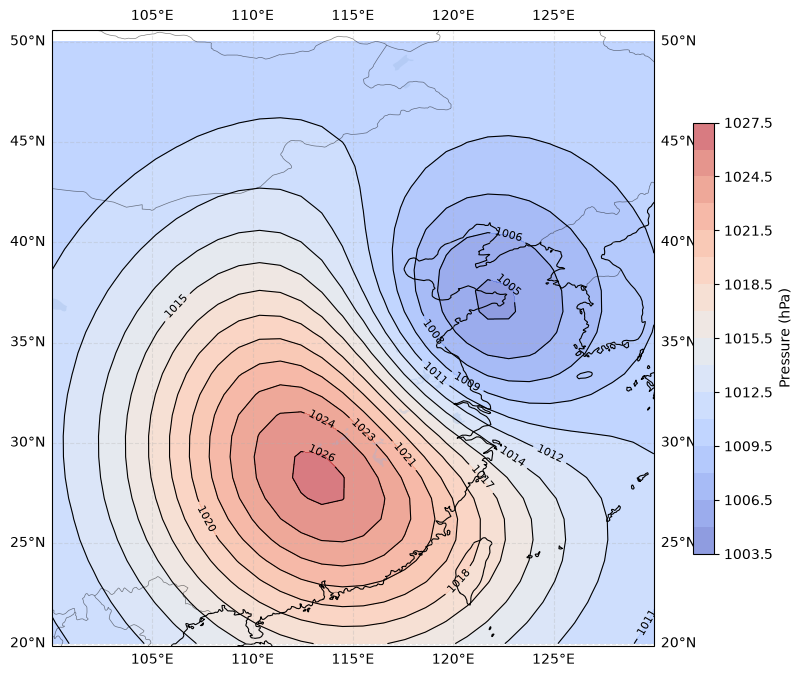

In [78]:
fig, ax = plt.subplots(figsize=(10, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

# 底图
ax.coastlines(resolution='50m', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.3)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
ax.set_extent([100, 130, 20, 50])

# 气压场叠加（注意 transform 参数！
contourf = ax.contourf(lon2d, lat2d, pressure, levels=15,
                       cmap='coolwarm', alpha=0.6,
                       transform=ccrs.PlateCarree())
fig.colorbar(contourf, ax=ax, label='Pressure (hPa)', shrink=0.7)

# 等值线
contour = ax.contour(lon2d, lat2d, pressure, levels=15,
                     colors='black', linewidths=0.8,
                     transform=ccrs.PlateCarree())
ax.clabel(contour, inline=True, fontsize=8, fmt='%d')

plt.show()

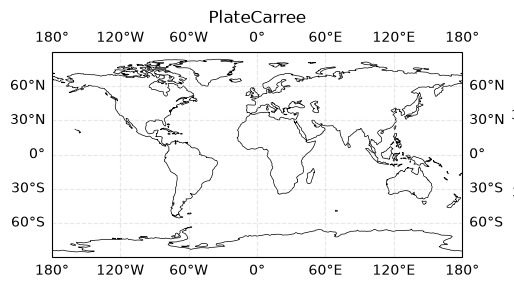

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={'projection': None})

projections = [
    ('PlateCarree', ccrs.PlateCarree(central_longitude=0)),
    ('Robinson', ccrs.Robinson(central_longitude=105)),
    ('NorthPolarStereo', ccrs.NorthPolarStereo()),
]

for ax, (name, proj) in zip(axes, projections):
    ax.remove()
    ax = fig.add_subplot(1, 3, list(axes).index(ax)+1, projection=proj)
    ax.set_global()
    ax.coastlines(resolution='110m', linewidth=0.5)
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
    ax.set_title(name)

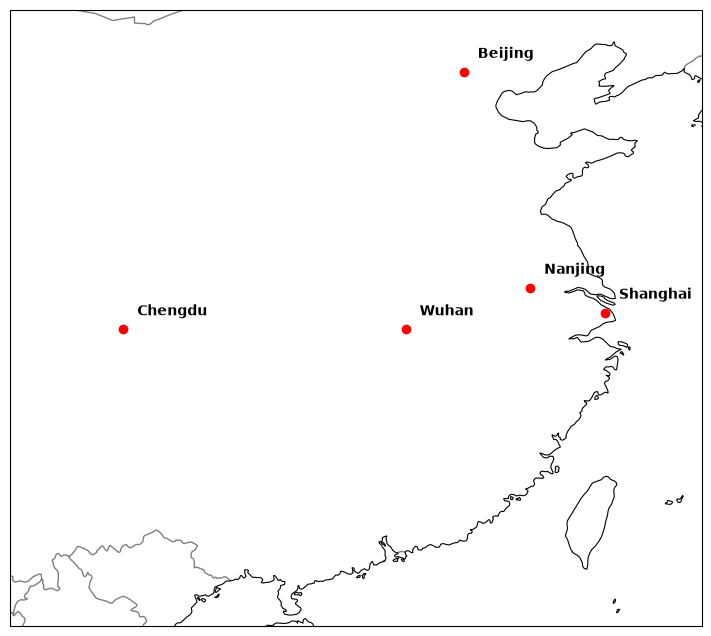

In [80]:
cities = {
    'Beijing': (116.4, 39.9),
    'Shanghai': (121.5, 31.2),
    'Nanjing': (118.8, 32.1),
    'Wuhan': (114.3, 30.6),
    'Chengdu': (104.1, 30.6),
}

fig, ax = plt.subplots(figsize=(10, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines(resolution='50m', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, alpha=0.5)
ax.set_extent([100, 125, 20, 42])

for city, (lon_c, lat_c) in cities.items():
    ax.plot(lon_c, lat_c, 'ro', markersize=6, transform=ccrs.PlateCarree())
    ax.text(lon_c + 0.5, lat_c + 0.5, city, transform=ccrs.PlateCarree(),
            fontsize=10, fontweight='bold')

plt.show()

In [81]:
# Cartopy 自带省界需要额外数据，也可以用 shapefile
# 方法1：Cartopy 内置
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)  # 美国州界


t850 形状: (15, 20)


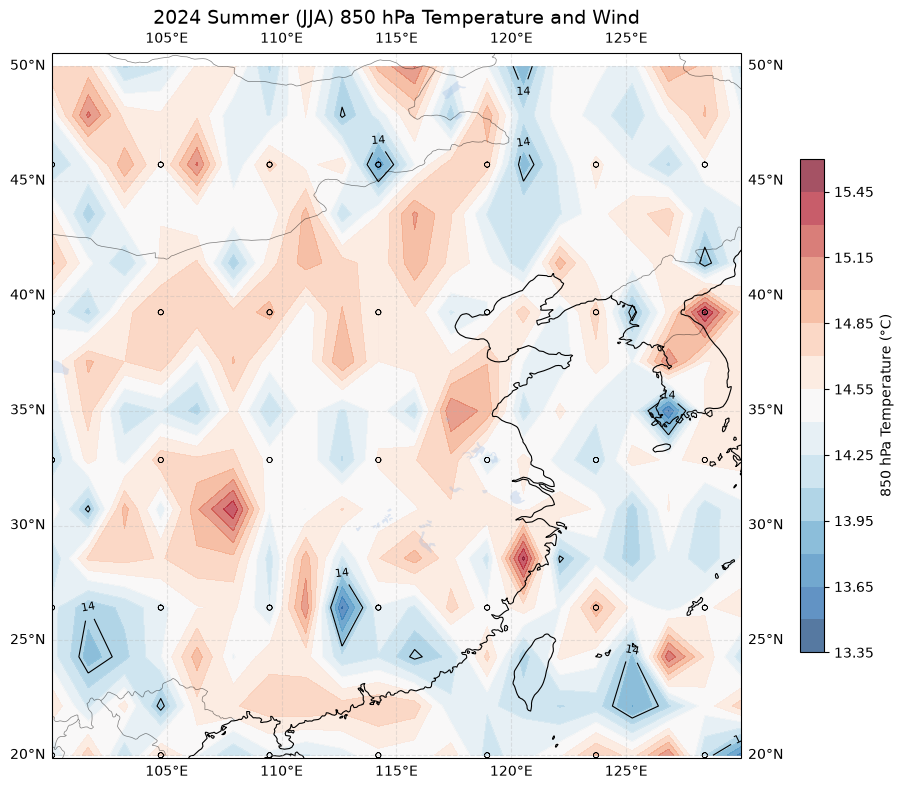

✅ 分析完成，图片已保存为 summer_850hPa.png


In [89]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---------- 1. 模拟数据 ----------
time = pd.date_range('2024-01-01', '2024-12-31', freq='D')
levels = [1000, 850, 700, 500, 200]
lat = np.linspace(20, 50, 15)
lon = np.linspace(100, 130, 20)

np.random.seed(42)
temp = np.random.randn(len(time), len(levels), len(lat), len(lon)) * 3 + 20
temp -= 0.0065 * np.array(levels)[:, np.newaxis, np.newaxis]

ds = xr.Dataset({
    'temperature': xr.DataArray(
        temp,
        dims=['time', 'level', 'lat', 'lon'],
        coords={'time': time, 'level': levels, 'lat': lat, 'lon': lon},
        attrs={'units': 'degC', 'long_name': 'Temperature'}
    ),
    'u': xr.DataArray(
        np.random.randn(len(time), len(levels), len(lat), len(lon)) * 5,
        dims=['time', 'level', 'lat', 'lon'],
        coords={'time': time, 'level': levels, 'lat': lat, 'lon': lon},
    ),
    'v': xr.DataArray(
        np.random.randn(len(time), len(levels), len(lat), len(lon)) * 5,
        dims=['time', 'level', 'lat', 'lon'],
        coords={'time': time, 'level': levels, 'lat': lat, 'lon': lon},
    ),
})

# ---------- 2. 数据预处理 ----------
# 选夏季（6-8月）
ds_jja = ds.sel(time=(ds.time.dt.month >= 6) & (ds.time.dt.month <= 8))
ds_jja_mean = ds_jja.mean(dim='time')

# 选850 hPa - 使用更安全的方式
t850 = ds_jja_mean['temperature'].sel(level=850)
print(f"t850 形状: {t850.shape}")  # 应该是 (15, 20)

# 提取风场数据
u850 = ds_jja_mean['u'].sel(level=850)
v850 = ds_jja_mean['v'].sel(level=850)

# ---------- 3. 绘图 ----------
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

# 地理要素
ax.coastlines(resolution='50m', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.3)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
ax.set_extent([100, 130, 20, 50])

# 创建网格
lon2d, lat2d = np.meshgrid(lon, lat)

# 温度填色
cf = ax.contourf(lon2d, lat2d, t850.values,
                 levels=15, cmap='RdBu_r', alpha=0.7,
                 transform=ccrs.PlateCarree())
fig.colorbar(cf, ax=ax, label='850 hPa Temperature (°C)', shrink=0.7)

# 等温线
cs = ax.contour(lon2d, lat2d, t850.values,
                levels=np.arange(0, 35, 2),
                colors='black', linewidths=0.8,
                transform=ccrs.PlateCarree())
ax.clabel(cs, inline=True, fontsize=8, fmt='%d')

# 风场箭头（隔点采样）
step = 3
ax.barbs(lon[::step], lat[::step],
         u850.values[::step, ::step],
         v850.values[::step, ::step],
         length=5, linewidth=0.5,
         transform=ccrs.PlateCarree())

ax.set_title('2024 Summer (JJA) 850 hPa Temperature and Wind', fontsize=14)

plt.tight_layout()
plt.savefig('summer_850hPa.png', dpi=200, bbox_inches='tight')
plt.show()

print('✅ 分析完成，图片已保存为 summer_850hPa.png')

In [88]:
def check_data(ds_jja_mean, level=850):
    """完整检查数据集"""
    print("=" * 50)
    print("数据集检查:")
    print(f"维度: {ds_jja_mean.dims}")
    print(f"变量: {list(ds_jja_mean.data_vars)}")
    
    # 检查 temperature 变量
    temp = ds_jja_mean['temperature']
    print(f"\ntemperature 维度: {temp.dims}")
    print(f"temperature 形状: {temp.shape}")
    print(f"temperature 坐标: {list(temp.coords.keys())}")
    
    # 检查 level 坐标
    if 'level' in temp.coords:
        print(f"可用的气压层: {temp.level.values}")
        if level in temp.level.values:
            print(f"✅ 找到 {level} hPa 层")
        else:
            print(f"❌ 未找到 {level} hPa 层")
            # 找到最近的层
            nearest = temp.level.values[np.argmin(np.abs(temp.level.values - level))]
            print(f"最近的层是: {nearest} hPa")
    else:
        print("⚠️ 数据中没有 level 坐标！")
    
    # 尝试提取
    try:
        t850 = temp.sel(level=level)
        print(f"\n提取后形状: {t850.shape}")
        if len(t850.shape) == 2:
            print(f"✅ 成功提取 2D 数据: {t850.dims}")
            return t850
        else:
            print(f"❌ 提取后的数据是 {len(t850.shape)}D")
            return None
    except Exception as e:
        print(f"❌ 提取失败: {e}")
        return None

# 使用
t850 = check_data(ds_jja_mean, 850)
if t850 is not None and len(t850.shape) == 2:
    # 绘图...
    pass

数据集检查:
维度: FrozenMappingWarningOnValuesAccess({'level': 5, 'lat': 15, 'lon': 20})
变量: ['temperature', 'u', 'v']

temperature 维度: ('level', 'lat', 'lon')
temperature 形状: (5, 15, 20)
temperature 坐标: ['level', 'lat', 'lon']
可用的气压层: [1000  850  700  500  200]
✅ 找到 850 hPa 层

提取后形状: (15, 20)
✅ 成功提取 2D 数据: ('lat', 'lon')
